🛰️ MintPy Daily-Use Code Repository — OpenSARLab Edition
Kernel Requirement: Every cell in this notebook must use the osl_mintpy kernel.
Check and switch it in the top-right corner of your Jupyter interface.
The default Python 3 kernel will fail with ModuleNotFoundError.

Universal Path Setup — Run This First in Every Session

**What it does:** Declares a master `DATA_DIR` variable pointing to your MintPy output folder.  
All 18 snippets below depend on this variable. Run this cell first, every time.

In [1]:
import os

# Change this to your actual MintPy geo-coded output folder in OpenSARLab.
# Typical OpenSARLab paths begin with /home/jovyan/
DATA_DIR = "/home/jovyan/dhaka/HyP3_downloads/MintPy"

# Verify the path actually exists before proceeding
if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"DATA_DIR not found: {DATA_DIR}\nCheck your path and try again.")

print(f"✅ Data directory confirmed: {DATA_DIR}")

✅ Data directory confirmed: /home/jovyan/dhaka/HyP3_downloads/MintPy


15 — Manually Plot a Single Pixel's Displacement Timeline

**What it does:** Extracts one pixel's complete displacement history from the 3D time-series
cube and plots it as a clean Matplotlib chart — bypassing the GUI entirely.  
**When to use:** When you need full control over the plot appearance (colors, fonts, markers,
annotations) for a research paper figure. Use Snippets 8/9 to find your target row/col first.

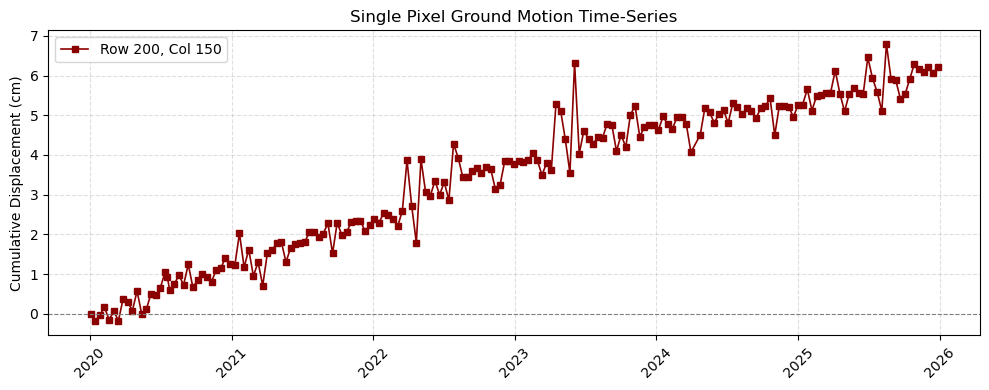

In [4]:
import os
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import h5py  # Using standard h5py to extract dates cleanly
from mintpy.utils import readfile

# Setup path 
DATA_DIR = "/home/jovyan/dhaka/HyP3_downloads/MintPy"
file_path = f"{DATA_DIR}/timeseries_ERA5_ramp_demErr.h5"

# Read data matrix and metadata dict
ts_data, meta = readfile.read(file_path)

# FIX: Safely pull dates using h5py directly from the HDF5 file keys
with h5py.File(file_path, 'r') as f:
    if 'date' in f.keys():
        # Read byte strings and decode to text strings
        raw_dates = [d.decode('utf-8') for d in f['date'][:]]
    elif 'DATES' in meta:
        raw_dates = meta['DATES'].split()
    else:
        # Emergency backup fallback
        raise KeyError(f"Could not locate date track. Available keys in file: {list(f.keys())}")

# Convert string dates (YYYYMMDD) into datetime objects for plotting
dates = [datetime.strptime(str(d), '%Y%m%d') for d in raw_dates]

# Update these with your real Row and Col numbers!
TARGET_ROW = 200   
TARGET_COL = 150   

unit = meta.get('UNIT', 'm')
scale = 100 if unit == 'm' else 1          # convert m → cm if needed
display_unit = 'cm' if unit == 'm' else unit

timeline = ts_data[:, TARGET_ROW, TARGET_COL] * scale

# Plotting the Time-Series
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates, timeline, 's-', color='darkred', markersize=4, linewidth=1.2, label=f"Row {TARGET_ROW}, Col {TARGET_COL}")
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel(f"Cumulative Displacement ({display_unit})")
ax.set_title("Single Pixel Ground Motion Time-Series")

# Rotate dates for readability
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()